#TASK 8 — Model Evaluation Metrics

##Importing Libraries

In [29]:
import pandas as pd
import os
import pickle
import joblib
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##Loading Files

In [24]:
loaded_models = {}
model_files = [
    '/content/lightgbm_model.pkl',
    '/content/random_forest_model.pkl',
    '/content/xgboost_model.pkl',
    '/content/logistic_regression_model.pkl',
    '/content/decision_tree_model.pkl'
]

for file_path in model_files:
    model_name = os.path.basename(file_path).replace('.pkl', '')
    try:
        with open(file_path, 'rb') as file:
            loaded_models[model_name] = pickle.load(file)
    except pickle.UnpicklingError:
        print(f"Warning: '{file_path}' is not a valid pickle file. Attempting to load with joblib...")
        try:
            loaded_models[model_name] = joblib.load(file_path) # joblib.load can take file_path directly
        except Exception as e:
            print(f"Error loading '{file_path}' with joblib: {e}. Skipping this model.")
    except Exception as e:
        print(f"An unexpected error occurred while loading '{file_path}': {e}. Skipping this model.")

if loaded_models:
    print("Models loaded successfully:", loaded_models.keys())
else:
    print("No models were loaded.")

Models loaded successfully: dict_keys(['lightgbm_model', 'random_forest_model', 'xgboost_model', 'logistic_regression_model', 'decision_tree_model'])


##Loading Dataset

In [ ]:
patient_feedback_featured = pd.read_csv('/content/patient_feedback_featured.csv')
patient_feedback_featured.head()

,Theme,Feedback,Sentiment,Satisfaction,Readmission,Feedback_Length,Word_Count,Theme_Sentiment_Ratio,about,admitted,...,very,wait,waiting,was,well,were,Theme_communication,Theme_discharge,Theme_medication,Theme_wait_time
0,discharge,discharge instructions were very clear,1,4,1,38,5,0.500000,0.000000,0.0,...,0.50346,0.0,0.0,0.0,0.0,0.376770,False,True,False,False
1,communication,i felt the doctor used too much medical jargon,1,5,0,46,9,0.714286,0.000000,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.000000,True,False,False,False
2,medication,i appreciated the reminders about my medicines,1,4,0,46,7,0.500000,0.407741,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.000000,False,False,True,False
3,discharge,instructions after discharge were not helpful,0,1,1,45,6,0.500000,0.000000,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.346345,False,True,False,False
4,discharge,instructions after discharge were not helpful,0,2,1,45,6,0.500000,0.000000,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.346345,False,True,False,False


##Loading x_test & y_test

In [ ]:
X_test = pd.read_csv('/content/X_test.csv')
X_test.head()

,Feedback_Length,Word_Count,Theme_Sentiment_Ratio,about,admitted,after,and,appointments,appreciated,before,...,very,wait,waiting,was,well,were,Theme_communication,Theme_discharge,Theme_medication,Theme_wait_time
0,46,9,0.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.000000,0.000000,0.00000,0.000000,True,False,False,False
1,38,4,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.000000,0.000000,0.00000,0.430012,False,False,True,False
2,25,5,0.307692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.428458,0.374249,0.00000,0.000000,False,False,False,True
3,41,6,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.000000,0.000000,0.47611,0.000000,False,False,True,False
4,38,5,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.50346,0.0,0.000000,0.000000,0.00000,0.376770,False,True,False,False


In [ ]:
y_test = pd.read_csv('/content/y_test.csv')
y_test.head()

,Sentiment
0,1
1,0
2,0
3,1
4,1


##Models Evaluation

In [26]:
results = {}

for model_name, model in loaded_models.items():
    try:
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[model_name] = accuracy
        print(f"Accuracy for {model_name}: {accuracy:.4f}")
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

print("\nEvaluation complete.")

Accuracy for lightgbm_model: 0.8421
Accuracy for random_forest_model: 1.0000
Accuracy for xgboost_model: 1.0000
Accuracy for logistic_regression_model: 1.0000
Accuracy for decision_tree_model: 1.0000

Evaluation complete.


##Confusion Matrices

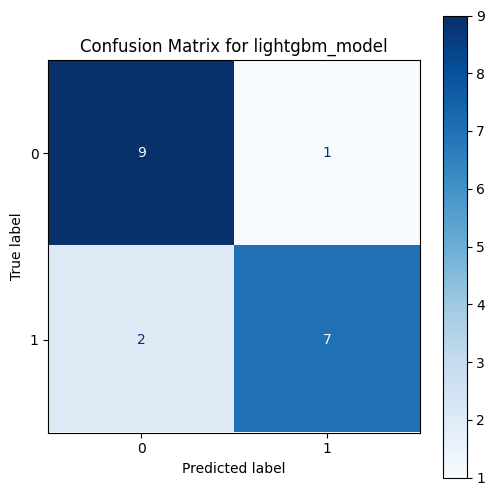

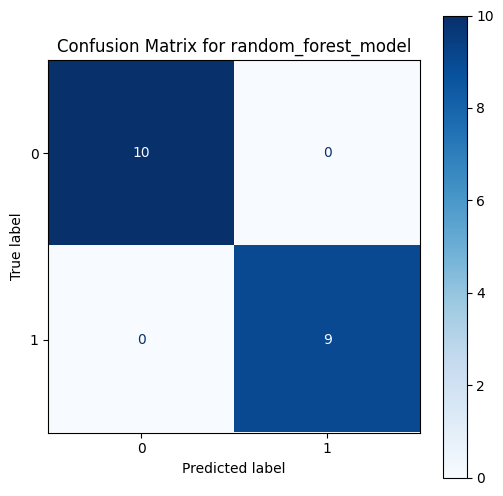

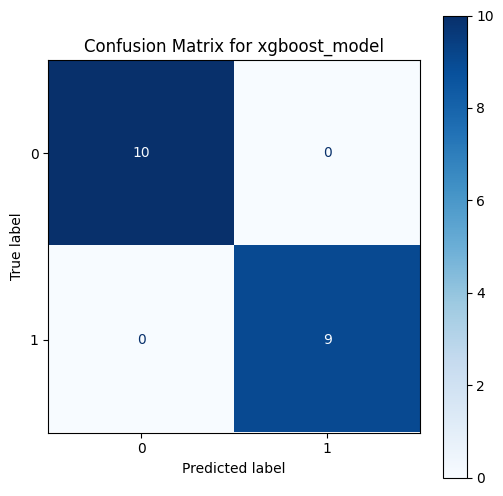

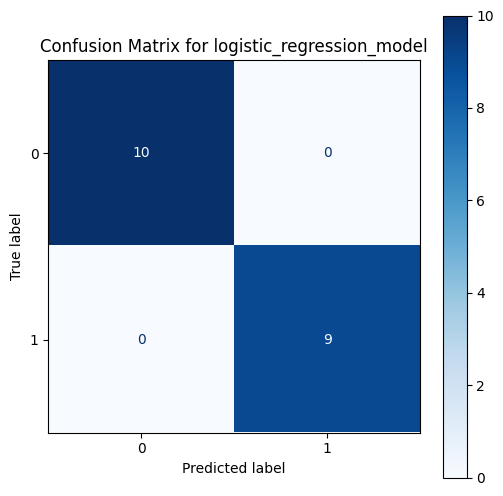

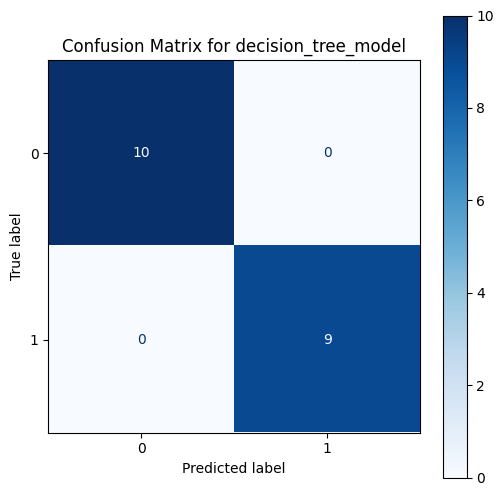

In [31]:
for model_name, model in loaded_models.items():
    try:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap=plt.cm.Blues, ax=ax)
        ax.set_title(f'Confusion Matrix for {model_name}')
        plt.show()
    except Exception as e:
        print(f"Error generating confusion matrix for {model_name}: {e}")